In [1]:
import torchvision
import numpy as np
import pandas as pd
from random import randint
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from tqdm import tqdm
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from time import time
import sklearn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import PIL
import os
import cv2

import warnings
warnings.filterwarnings('ignore')

/opt/conda/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 1.4.20 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
using_colab = True
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything-2.git'

    !mkdir -p images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything-2/main/notebooks/images/cars.jpg

    !mkdir -p ../checkpoints/
    !wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt

PyTorch version: 2.4.0
Torchvision version: 0.19.0
CUDA is available: True
  Cloning https://github.com/facebookresearch/segment-anything-2.git to /tmp/pip-req-build-1xnybtmz
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything-2.git /tmp/pip-req-build-1xnybtmz
  Resolved https://github.com/facebookresearch/segment-anything-2.git to commit c2ec8e14a185632b0a5d8b161928ceb50197eddc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.5 MB/s eta 0:00:00
  Created wheel for SAM-2

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

if device.type == "cuda":
    print("Using b16-float")
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    
device

Using b16-float


device(type='cuda', index=0)

In [4]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)
    return img

In [79]:
def convert_filename_format1_to_format2(filename):
    # Remove "CXR" prefix
    without_prefix = filename.replace('CXR', '')
    # Replace "/<index>.png" with "-1001.dcm.png"
    converted_filename = without_prefix.replace('/0.png', '-1001.dcm.png')
    return converted_filename

In [89]:
images_path = "/kaggle/input/chest-xrays-indiana-university/images/images_normalized/"
ids_df = pd.read_csv("/kaggle/input/chest-xrays-indiana-university/indiana_projections.csv")
reports_df = pd.read_csv("/kaggle/input/chest-xrays-indiana-university/indiana_reports.csv")
image_files_subset = sorted(os.listdir(images_path))
df = pd.merge(ids_df, reports_df, on="uid")
df_subset = df[df["filename"].isin(image_files_subset)]

In [90]:
df_subset[df_subset["filename"]=="1_IM-0001-4001.dcm.png"].findings.iloc[0]

'The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.'

In [91]:
import json

def convert_jsonl_to_json(input_jsonl_file):
    # Determine the output JSON filename
    base_name = os.path.splitext(os.path.basename(input_jsonl_file))[0]
    
    # Read the JSONL file and aggregate the data
    data = []
    with open(input_jsonl_file, 'r') as jsonl_file:
        for line_number, line in enumerate(jsonl_file, start=1):
            line = line.strip()
            if not line:  # Skip empty lines
                continue
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON on line {line_number}: {e}")
                continue
    
    return data


input_jsonl_file = '/kaggle/input/iuxray-vqa/iuxray_test.jsonl'
json_data = convert_jsonl_to_json(input_jsonl_file)

In [92]:
# sorted(df_subset["filename"].values)

In [93]:
json_df = pd.DataFrame(json_data)
json_filtered_df = json_df[json_df['answer'].str.len() <= 5]

In [97]:
json_filtered_df['filename'] = json_filtered_df['image'].apply(convert_filename_format1_to_format2)

In [100]:
json_filtered_df

,question,answer,image,question_id,text,report,converted_filename,filename
0,Does the cardiomediastinal silhouette appear n...,Yes.,CXR3030_IM-1405/0.png,1,Does the cardiomediastinal silhouette appear n...,Normal cardiomediastinal silhouette. There is ...,3030_IM-1405-1001.dcm.png,3030_IM-1405-1001.dcm.png
1,Does the patient have a large pleural effusion...,No.,CXR3030_IM-1405/0.png,2,Does the patient have a large pleural effusion...,Normal cardiomediastinal silhouette. There is ...,3030_IM-1405-1001.dcm.png,3030_IM-1405-1001.dcm.png
2,Can any acute bony abnormalities be seen in th...,No.,CXR3030_IM-1405/0.png,3,Can any acute bony abnormalities be seen in th...,Normal cardiomediastinal silhouette. There is ...,3030_IM-1405-1001.dcm.png,3030_IM-1405-1001.dcm.png
5,Does the chest X-ray show any signs of lung in...,No,CXR38_IM-1911/0.png,6,Does the chest X-ray show any signs of lung in...,Lungs are clear. There is no pneumothorax or p...,38_IM-1911-1001.dcm.png,38_IM-1911-1001.dcm.png
6,Can pleural effusion be seen in the chest X-ra...,No,CXR38_IM-1911/0.png,7,Can pleural effusion be seen in the chest X-ra...,Lungs are clear. There is no pneumothorax or p...,38_IM-1911-1001.dcm.png,38_IM-1911-1001.dcm.png
...,...,...,...,...,...,...,...,...
2566,Does the chest X-ray reveal any signs of lung ...,No.,CXR2312_IM-0887/0.png,2567,Does the chest X-ray reveal any signs of lung ...,The heart is normal in size. The mediastinum i...,2312_IM-0887-1001.dcm.png,2312_IM-0887-1001.dcm.png
2568,Is the heart size normal on the chest X-ray im...,Yes.,CXR49_IM-2110/0.png,2569,Is the heart size normal on the chest X-ray im...,"The heart, pulmonary XXXX and mediastinum are ...",49_IM-2110-1001.dcm.png,49_IM-2110-1001.dcm.png
2569,Can we see any pleural effusion on the chest X...,No.,CXR49_IM-2110/0.png,2570,Can we see any pleural effusion on the chest X...,"The heart, pulmonary XXXX and mediastinum are ...",49_IM-2110-1001.dcm.png,49_IM-2110-1001.dcm.png
2570,Are there visible degenerative changes of the ...,Yes.,CXR49_IM-2110/0.png,2571,Are there visible degenerative changes of the ...,"The heart, pulmonary XXXX and mediastinum are ...",49_IM-2110-1001.dcm.png,49_IM-2110-1001.dcm.png


In [108]:
vqa_df = pd.merge(json_filtered_df, df_subset[["projection", "MeSH", "filename", "Problems", "indication"]], on="filename")

In [109]:
vqa_df.to_csv("iu-xray-vqa.csv", index=False)

In [124]:
image_sample = cv2.resize(np.array(Image.open(images_path + vqa_df["filename"].values[0]).convert("RGB")), (256,256))

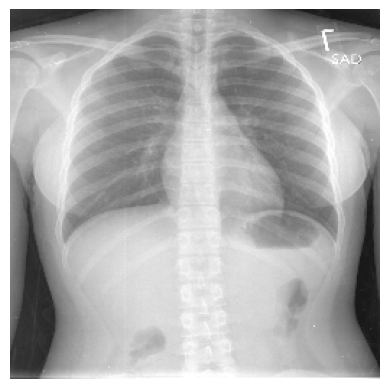

In [125]:
plt.imshow(image_sample)
plt.axis("off")
plt.show()

In [130]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "../checkpoints/sam2_hiera_large.pt"
model_cfg = "sam2_hiera_l.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=True)

mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=16,
    points_per_batch=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.7,
    stability_score_offset=1.3,
    crop_n_layers=1,
    box_nms_thresh=0.8,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100.0,
    use_m2m=True,
    multimask_output=True
)

In [131]:
def get_sam_results(image):
    sam_result = mask_generator.generate(image)
    return sam_result

In [132]:
sam_result = get_sam_results(image_sample)

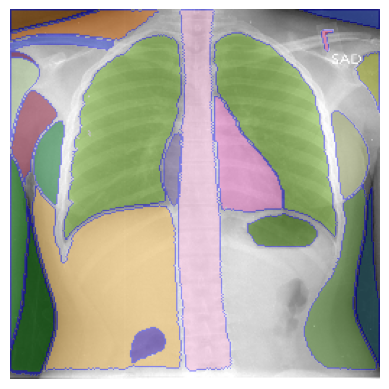

In [133]:
plt.imshow(image_sample)
show_anns(sam_result)
plt.axis("off")
plt.show()

In [134]:
vqa_files = vqa_df["filename"].values

In [135]:
sam_results = []

for file in tqdm(vqa_files[:500]):
    image_sample = cv2.resize(np.array(Image.open(images_path + file).convert("RGB")), (256,256))
    sam_result = get_sam_results(image_sample)
    sam_results.append({
        "filename" : file,
        "sam" : sam_result
    })
    

100%|██████████| 500/500 [1:08:13<00:00,  8.19s/it]


In [137]:
import pickle
with open('iu-xray.pkl', 'wb') as f:
    pickle.dump(sam_results, f)